In [21]:
import cooler
import cooltools
import pandas as pd
from ggner_3d.cm import CLR_CONNS, get_expected_cis_df, prepare_view_df
from ggner_3d.boundaries import preserved_boundaries_only, make_tads
import bioframe as bf

from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np

resolution = 10_000
window = 500_000
clr_ = CLR_CONNS(resolution=resolution)
expected_ = {
    k: get_expected_cis_df(k, resolution_kb=resolution // 1000, label='chrom')
    for k in clr_.keys()
}

In [ ]:
sample_names = ['WTnoUV', 'WT3h', 'XPCnoUV', 'XPC3h']
insulation_table_ = [
    pd.read_csv(f'/home/carlos/Clone/ggner-3d/data/insulation/insulation_{name}_10000bp.csv') for name in sample_names
]
comparisons = [(0,1), (0,2), (2,3)]
comparisons_str = ['WTnoUV_WT3h', 'WTnoUV_XPCnoUV', 'XPCnoUV_XPC3h']
accepted_range = 1
results, dfs = preserved_boundaries_only(
    comparisons=comparisons,
    comparisons_str=comparisons_str,
    sample_names_str=sample_names,
    accepted_range=accepted_range,
    insulation_table_=insulation_table_,
    window=window,
)

In [ ]:
def chrom_to_bin_indices(df, bins_table, bin_column = 'idx1'):
    df = df.copy()
    bins_table['indices'] = bins_table.index
    return pd.merge(df, bins_table, left_on=bin_column, right_on='indices')

bins_table = clr_['WTnoUV'].bins()[:]

dfs = [
    chrom_to_bin_indices(df, bins_table, bin_column='idx1') for df in dfs
]

In [ ]:
tads_ = {
    comp: make_tads(bf.sort_bedframe(df[['chrom', 'start', 'end']]), maxlen=3e6) for comp, df in zip(comparisons_str, dfs)
}

In [32]:
view_df = prepare_view_df(arm=False)

saddle_results = {}

chrom_oi = 'chr15'
for comp, tad_df in tads_.items():
    current_tad_df = tad_df[tad_df['chrom'] == chrom_oi].copy()
    current_tad_df['tad_id'] = current_tad_df.index
    current_tad_df['start'] += resolution // 2
    current_tad_df['end'] -= resolution // 2
    ntads = len(current_tad_df)
    print(f'{comp}: {ntads} TADs in {chrom_oi}')
    current_tad_track = bf.overlap(bins_table.loc[bins_table['chrom'] == chrom_oi], current_tad_df)
    current_tad_track = current_tad_track[['chrom', 'start', 'end', 'tad_id_']]
    NBINS = ntads
    QRANGE = (0,1)
    
    s1, s2 = comp.split('_')
    clr1 = clr_[s1]
    clr2 = clr_[s2]
    expected1 = expected_[s1].loc[expected_[s1]['region1'] == chrom_oi].copy().reset_index(drop=True)
    expected2 = expected_[s2].loc[expected_[s2]['region1'] == chrom_oi].copy().reset_index(drop=True)
    view_df_now = view_df.loc[view_df['chrom'] == chrom_oi].copy().reset_index(drop=True)

    s1_sum, s1_count = cooltools.api.saddle.saddle(
        clr1,
        expected=expected1,
        contact_type='cis',
        track=current_tad_track,
        n_bins=NBINS,
        qrange=QRANGE,
        view_df=view_df_now
    )

    s2_sum, s2_count = cooltools.api.saddle.saddle(
        clr2,
        expected=expected2,
        contact_type='cis',
        track=current_tad_track,
        n_bins=NBINS,
        qrange=QRANGE,
        view_df=view_df_now
    )
    
    saddle_results[comp] = {
        s1: s1_sum / s1_count,
        s2: s2_sum / s2_count,
    }

    break

WTnoUV_WT3h: 75 TADs in chr15


/home/carlos/Clone/ggner-3d/.venv/lib/python3.12/site-packages/cooltools/lib/checks.py:550: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in track.groupby(track.columns[0]):
/home/carlos/Clone/ggner-3d/.venv/lib/python3.12/site-packages/cooltools/lib/common.py:489: UserWarning: less than 50% of valid bins have been assigned a value
  warnings.warn("less than 50% of valid bins have been assigned a value")
/home/carlos/Clone/ggner-3d/.venv/lib/python3.12/site-packages/cooltools/lib/checks.py:550: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in track.groupby(track.columns[0]):
/h

<Axes: >

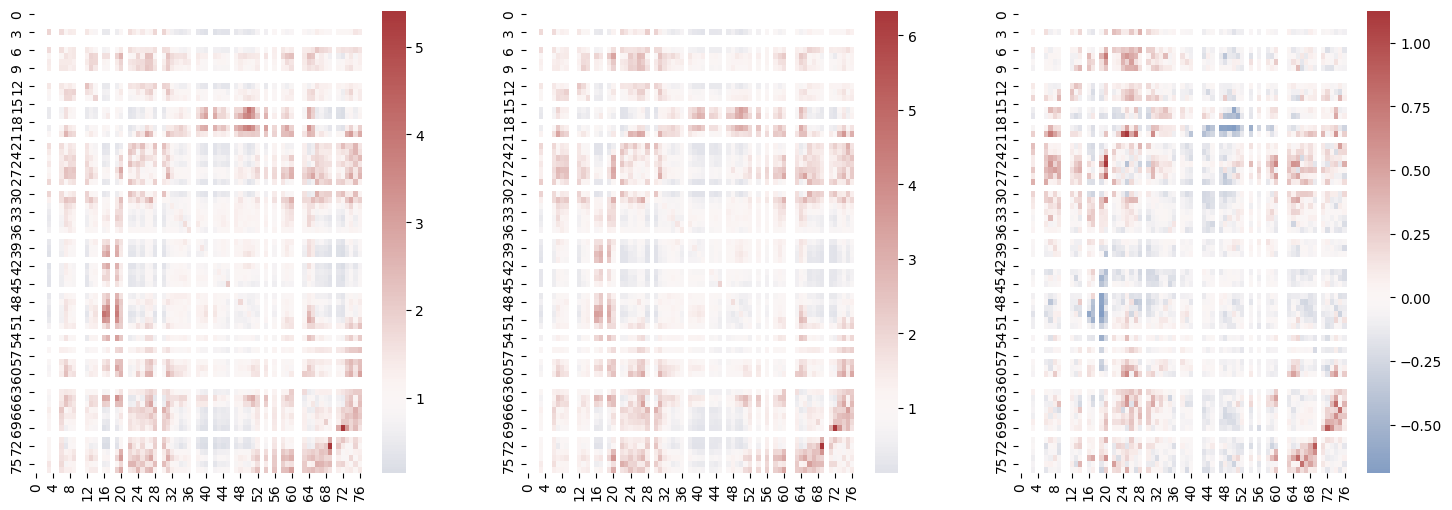

In [33]:
s1_saddle = saddle_results['WTnoUV_WT3h']['WTnoUV']
s2_saddle = saddle_results['WTnoUV_WT3h']['WT3h']

ignore_diag = 0
def mask_diag(mat, ignore_diag):
    mat = mat.copy()
    if ignore_diag <= 0:
        return mat
    for i in range(-ignore_diag, ignore_diag + 1):
        mat = cooltools.lib.numutils.set_diag(mat, np.nan, i=i)
    return mat

s1_saddle = mask_diag(s1_saddle, ignore_diag)
s2_saddle = mask_diag(s2_saddle, ignore_diag)
import seaborn as sns
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

diff = s2_saddle - s1_saddle
sns.heatmap(s1_saddle, ax=axs[0], cmap='vlag', center=1)
sns.heatmap(s2_saddle, ax=axs[1], cmap='vlag', center=1)
sns.heatmap(diff, ax=axs[2], cmap='vlag', center=0)